### import packages

- use instructor instead of langchain

In [1]:
from pydantic import BaseModel

from langsmith import traceable, get_current_run_tree

import instructor

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send

from langchain_core.messages import SystemMessage
from IPython.display import Image, display

from typing import Literal, Dict, Any, Annotated, List
from operator import add

import random
import openai
import pandas as pd

from jinja2 import Template

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

In [2]:
from dotenv import load_dotenv

load_dotenv("../../.env")

True

In [3]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding


def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }


def process_context(context):

    formatted_context = ""

    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

In [4]:
qdrant_client = QdrantClient(url="http://localhost:6333")

In [5]:
query = "Can I get a tablet?"
answer = retrieve_data(query, qdrant_client, k=10)
answer

{'retrieved_context_ids': ['B07Q38R2XF',
  'B07L8HX46F',
  'B0BGHMDZHG',
  'B08Z3N1YTR',
  'B00Y1NGRM2',
  'B004M5H6D8',
  'B08DNC3L4M',
  'B081122SFR',
  'B08DMY7S84',
  'B00B3507Q8'],
 'retrieved_context': ['ASURION 2 Year Tablet Accident Protection Plan ($30 - $39.99) NO ADDITIONAL COST: You pay $0 for repairs – parts, labor and shipping included. COVERAGE: Plan starts on the date of purchase. Drops, spills and cracked screens due to normal use are covered from day one. Malfunctions are covered after the manufacturer’s warranty. EASY CLAIMS PROCESS: File a claim anytime online at www.Asurion.com/Amazon or by phone. Most claims approved within minutes. We will send you an Amazon e-gift card for the purchase price of your covered product. In some cases, we will replace or repair it. EXPERT TECH HELP: Real experts are available 24/7 to help with set-up, connectivity issues, troubleshooting and much more. TERMS & DETAILS: More information about this protection plan is available within t

### Multi-intent Questions

In [6]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
answer = retrieve_data(query, qdrant_client, k=10)

In [7]:
answer['retrieved_context']

["Hyjoy 8 inch Kids Tablet, IPS HD Display, Android 10 Tablet PC, 2GB RAM, 32GB Storage, WiFi, Bluetooth, Dual Camera, Games, Parental Control, Kidoz Installed, with Kids-Tablet Case (Blue) ✅【New Favorite for Kids】HYJOY kids tablet 8 inch is specially designed for kids and comes preinstalled with popular app FamilyGroup, has an advanced parental control password protection system, screen time setting, security modes, and surfing content management. Creates a safe, clean online environment for entertainment. ✅【FHD IPS Touch Screen & Google Play】This kids tablet has a IPS FHD touchscreen that provides an outstanding visual experience. This android tablet gives you full access to Google Play to download a large number of up-to-date educational apps. The 8 inch kids tablet LCD is designed with low blue light technology. With one click you can enter reading mode, reducing screen flicker and eye damage casued by irritating blue light. Greater comfort and safety for your kids' devices. ✅【High

In [8]:
# define pydantic model first
class QueryExpandResponse(BaseModel):
    statements: List[str] # a list of strings


def query_expansion_node(query) -> dict:
    # different statement capture different intent

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "queries": response.statements
    }

In [9]:
answer = query_expansion_node(query)
answer

{'queries': ['Kid-friendly tablet',
  'Smartwatch for personal use',
  'Laptop for work or home use']}

### langraph
- Query Expansion (Sequential Execution)

In [10]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""

- Query Expansion / Rewriting Node

In [11]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [12]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

- Retriever Node

In [13]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")

    retrieved_context = []

    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, qdrant_client, k=5))

    return {
        "retrieved_context": retrieved_context
    }

- Aggregator Node

In [14]:
class AggregatorResponse(BaseModel):
    answer: str


@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

In [15]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

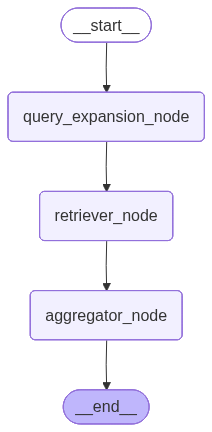

In [16]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

initial_state = {
    "initial_query": query
}

In [18]:
result = graph.invoke(initial_state)

In [19]:
print(result["answer"])

Yes — based on the available products, here are suitable options for each person:

- For your kid: Hyjoy 8 inch Kids Tablet (ID: B0BGHMDZHG)
  - 8 inch IPS FHD touch display
  - Android 10.0 with GMS certification
  - 2GB RAM and 32GB storage
  - Expandable microSD support up to 128GB
  - WiFi and Bluetooth
  - Dual camera
  - Preinstalled kids apps and parental controls
  - Kidoz installed
  - 4000mAh battery, up to about 6 hours of mixed use
  - Includes a food-grade silicone protective case
  - Suitable for children aged 2–10

- For you: KALINCO Smart Watch for Android Phones iOS (ID: B0BP7PBLHM)
  - 1.3 inch HD screen
  - 24/7 heart rate monitoring
  - Sleep monitoring
  - 5ATM waterproof
  - 18 sports modes
  - Custom watch face support via uploaded picture
  - Message/call notifications from paired phone
  - Compass, music control, alarm, schedule, and remote camera support
  - Compatible with iOS and Android via app

- For your wife: 2021 Newest HP 14 Inch Non-Touch Premium Lapt

### query expansion (parallel execution)

In [20]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = [] # langchain would add [] together from different nodes
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

- Query Expansion / Rewriting Node

In [21]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [22]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

In [23]:
def query_expand_conditional_edges(state: State) -> dict:

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )

    return send_messages

- Retriever Node

In [24]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    hybrid = True

    qdrant_client = QdrantClient(url="http://localhost:6333")

    query_embedding = get_embedding(state["query"])

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=state["k"]
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=state["k"]
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

- Aggregator Node

In [25]:
class AggregatorResponse(BaseModel):
    answer: str

@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

In [26]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges
)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

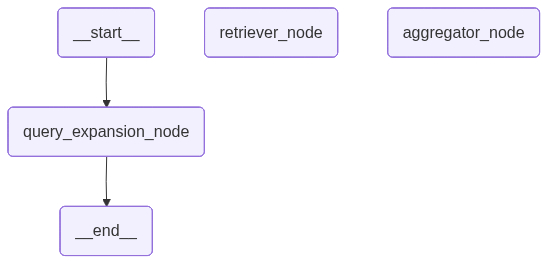

In [27]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

In [29]:
initial_state = {
    "initial_query": query
}

In [30]:
result = graph.invoke(initial_state)

In [31]:
# # do not see trace, let try this instead
# from dotenv import load_dotenv
# from langsmith import traceable, Client
# import os
# load_dotenv("../../.env", override=True)
# print(os.environ.get("LANGSMITH_TRACING"))
# print(os.environ.get("LANGSMITH_PROJECT"))
# print(bool(os.environ.get("LANGSMITH_API_KEY")))
# @traceable(name="query_rerank_graph")
# def run_graph(initial_state):
#     return graph.invoke(initial_state)
# result = run_graph(initial_state)
# Client().flush()

In [32]:
print(result["answer"])

- Tablet for your kid: Yes — available products include the Hyjoy 8 inch Kids Tablet (ID: B0BGHMDZHG), which is designed for children with parental controls and a protective case.
  - 8 inch IPS FHD touch screen
  - Android 10.0, GMS certified
  - 2GB RAM and 32GB storage, expandable via microSD up to 128GB
  - WiFi, Bluetooth, dual camera
  - Preinstalled kids apps and parental control features
  - 4000mAh battery, up to 6 hours mixed use
  - Includes a food-grade silicone protective case

- Watch for you: No watch is listed in the available products.

- Laptop for your wife: Yes — available products include several laptops, such as:
  - HP 14 Inch Non-Touch Premium Laptop (ID: B0895HGXZT)
    - 14-inch HD anti-glare display
    - AMD Athlon Silver 3050U processor
    - 4GB DDR4 RAM
    - 128GB SSD
    - WiFi, HDMI, Windows 10 in S
  - Dell Inspiron 15 3501 (ID: B09M7Q8N8R)
    - 15.6-inch FHD anti-glare display
    - Intel Core i7-1165G7 processor
    - 16GB DDR4 RAM
    - 512GB SSD
